In [1]:
from desc import set_device
set_device("gpu")
import numpy as np
from desc.objectives import TrappedResonance
from desc.equilibrium import Equilibrium
import matplotlib.pyplot as plt

In [2]:
eq = Equilibrium.load("precise_QA_output.h5")[-1]

Ekin_frac = 1e-5
s_min = 0.7
s_max = 0.9
pp = 0
qq = 1
num_rho = 30
knots_per_transit = 40
num_quad = 20
num_transit = 5
num_well = 1
num_eta = 30

data = np.load("poincare_data_Bcrit_1.08.npz")

Bcrit = 1/data['lam'][()]

# rho grid matches TrappedResonance's internal np.linspace(0, 1, num_rho + 1)[1:]
rhos = np.linspace(0, 1, num_rho + 1)[1:]
s_prof = rhos**2

obj = TrappedResonance(
    eq, num_rho=num_rho, num_eta=num_eta, M=1, N=0,
    pitch_invs=np.array([Bcrit]),
    num_well=num_well, num_transit=num_transit,
    knots_per_transit=knots_per_transit, num_quad=num_quad, KE_frac=Ekin_frac,
)
obj.build()
val = obj.compute(eq.params_dict)

Precomputing transforms


In [3]:
np.savez("desc_debug.npz", val=val)
val = np.load("desc_debug.npz",allow_pickle=True)['val'][()]
valid = np.isfinite(val['Delta_s'][0,0,:])
Delta_s = val['Delta_s'][0,0,valid]
s_res = val['s_res'][0,0,valid]
p_arr = val['p_arr'][valid]
q_arr = val['q_arr'][valid]
Omega = val['Omega'][:,0,0]
res_weight = val['res_weight'][:,0,0,valid]

In [4]:
freq_data = np.load("trapped_frequencies.npz",allow_pickle=True)

omega_b = freq_data['omega_b_prof'][()]
omega_zeta = freq_data['omega_zeta_prof'][()]

Omega_firm3d = 2 * omega_zeta/omega_b
lam_values = freq_data['lam_values'][()]
lam_index = np.argmin(np.abs(1/lam_values - Bcrit))
Omega_firm3d = Omega_firm3d[lam_index]
s_firm3d = freq_data['s_prof'][()][lam_index]

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_394103/1550972556.py:5: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel('$\Omega$')


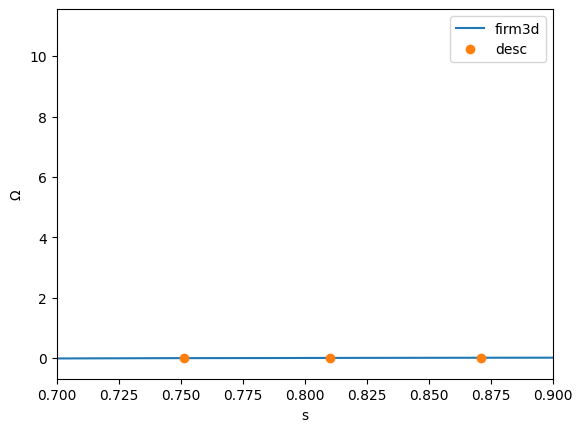

In [5]:
plt.figure()
plt.plot(s_firm3d,Omega_firm3d,'-',label='firm3d')
plt.plot(s_prof,Omega,'o',label='desc')
plt.xlabel('s')
plt.ylabel('$\Omega$')
plt.xlim(s_min,s_max)
plt.legend()
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:11: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_394103/256792151.py:11: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\eta$')


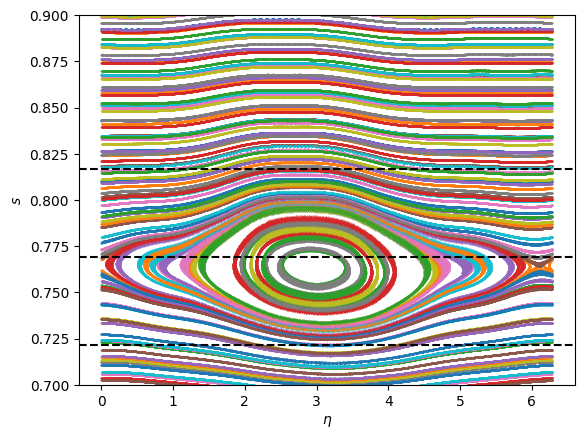

In [6]:
s_poinc = data['s_all']
etas_poinc = np.mod(data['etas_all'], 2*np.pi)

plt.figure()
for i in range(len(s_poinc)):
    plt.scatter(etas_poinc[i],s_poinc[i],s=0.1)
plt.ylim(s_min,s_max)
plt.axhline(s_res[(p_arr == 0) & (q_arr == 1)], color='k', linestyle='--')
plt.axhline(s_res[(p_arr == 0) & (q_arr == 1)] + 0.5*Delta_s[(p_arr == 0) & (q_arr == 1)], color='k', linestyle='--')
plt.axhline(s_res[(p_arr == 0) & (q_arr == 1)] - 0.5*Delta_s[(p_arr == 0) & (q_arr == 1)], color='k', linestyle='--')
plt.xlabel('$\eta$')
plt.ylabel('$s$')
plt.show()